In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split


# Dataset Overview


In [2]:
df=pd.read_csv('/content/drive/MyDrive/AI_ML/Datasets/House_Pricing.csv')
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [3]:
df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,Fair,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


#

# Understanding the dataset

In [17]:
#To know how many rows and columns
df.shape


(21613, 21)

In [4]:
#To datatypes of cols
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [18]:
#To get basic information about cols
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         21613 non-null  int64         
 1   Date House was Sold                        21613 non-null  datetime64[ns]
 2   Sale Price                                 21609 non-null  float64       
 3   No of Bedrooms                             21613 non-null  int64         
 4   No of Bathrooms                            21609 non-null  float64       
 5   Flat Area (in Sqft)                        21604 non-null  float64       
 6   Lot Area (in Sqft)                         21604 non-null  float64       
 7   No of Floors                               21613 non-null  float64       
 8   Waterfront View                            21613 non-null  object        
 9   No of Times Visit

In [19]:
#To know numeric cols
df.select_dtypes(include='number').columns

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [20]:
#To know categorical cols
df.select_dtypes(include='object').columns

Index(['Waterfront View', 'No of Times Visited', 'Condition of the House'], dtype='object')

In [21]:
#To summarise numeric col
df.describe()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,21613,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,2017-03-05 23:14:37.638458112,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
min,1.000102e+06,2016-01-15 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2016-04-15 00:00:00,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2017-06-14 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2017-09-14 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2017-12-14 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631


# Finding duplicate values

In [24]:
#To count duplicate rows
df.duplicated().sum()

np.int64(0)

In [25]:
#To get duplicated cols
df.columns.duplicated().sum()

np.int64(0)

In [44]:
#Changing data type of 'Date House was Sold' from object to datetime
df['Date House was Sold']=pd.to_datetime(df['Date House was Sold'])
df['No of Bathrooms']=pd.to_numeric(df['No of Bathrooms'])
df['No of Bathrooms']

,No of Bathrooms
0,1.00
1,2.25
2,1.00
3,3.00
4,2.00
...,...
21608,2.50
21609,2.50
21610,0.75
21611,2.50


# Handling Missing Values

In [32]:
df.isna().sum()[lambda x:x>0]

,0
Sale Price,4
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Times Visited,19489
Area of the House from Basement (in Sqft),3
Zipcode,1
Latitude,1
Longitude,1
Living Area after Renovation (in Sqft),1


In [30]:
((df.isna().sum())/len(df)*100)[lambda x:x>0]

,0
Sale Price,0.018507
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Times Visited,90.172581
Area of the House from Basement (in Sqft),0.013881
Zipcode,0.004627
Latitude,0.004627
Longitude,0.004627
Living Area after Renovation (in Sqft),0.004627


In [34]:
#Missing value between 0-2%  rows are dropped
df.dropna(subset=['Zipcode',
                  'Latitude',
                  'Longitude',
                  'Living Area after Renovation (in Sqft)',
                  'Area of the House from Basement (in Sqft)',
                  'No of Bathrooms',
                  'Flat Area (in Sqft)',
                  'Lot Area (in Sqft)',
                  'Sale Price',
                  'No of Bathrooms',
            ],inplace=True)

In [38]:
#Missing value column upto 90% is dropped from dataset
df.drop(columns=['No of Times Visited'],inplace=True)

In [39]:
df.isna().sum()[lambda x:x>0]

,0


# Handling an detecting outliers

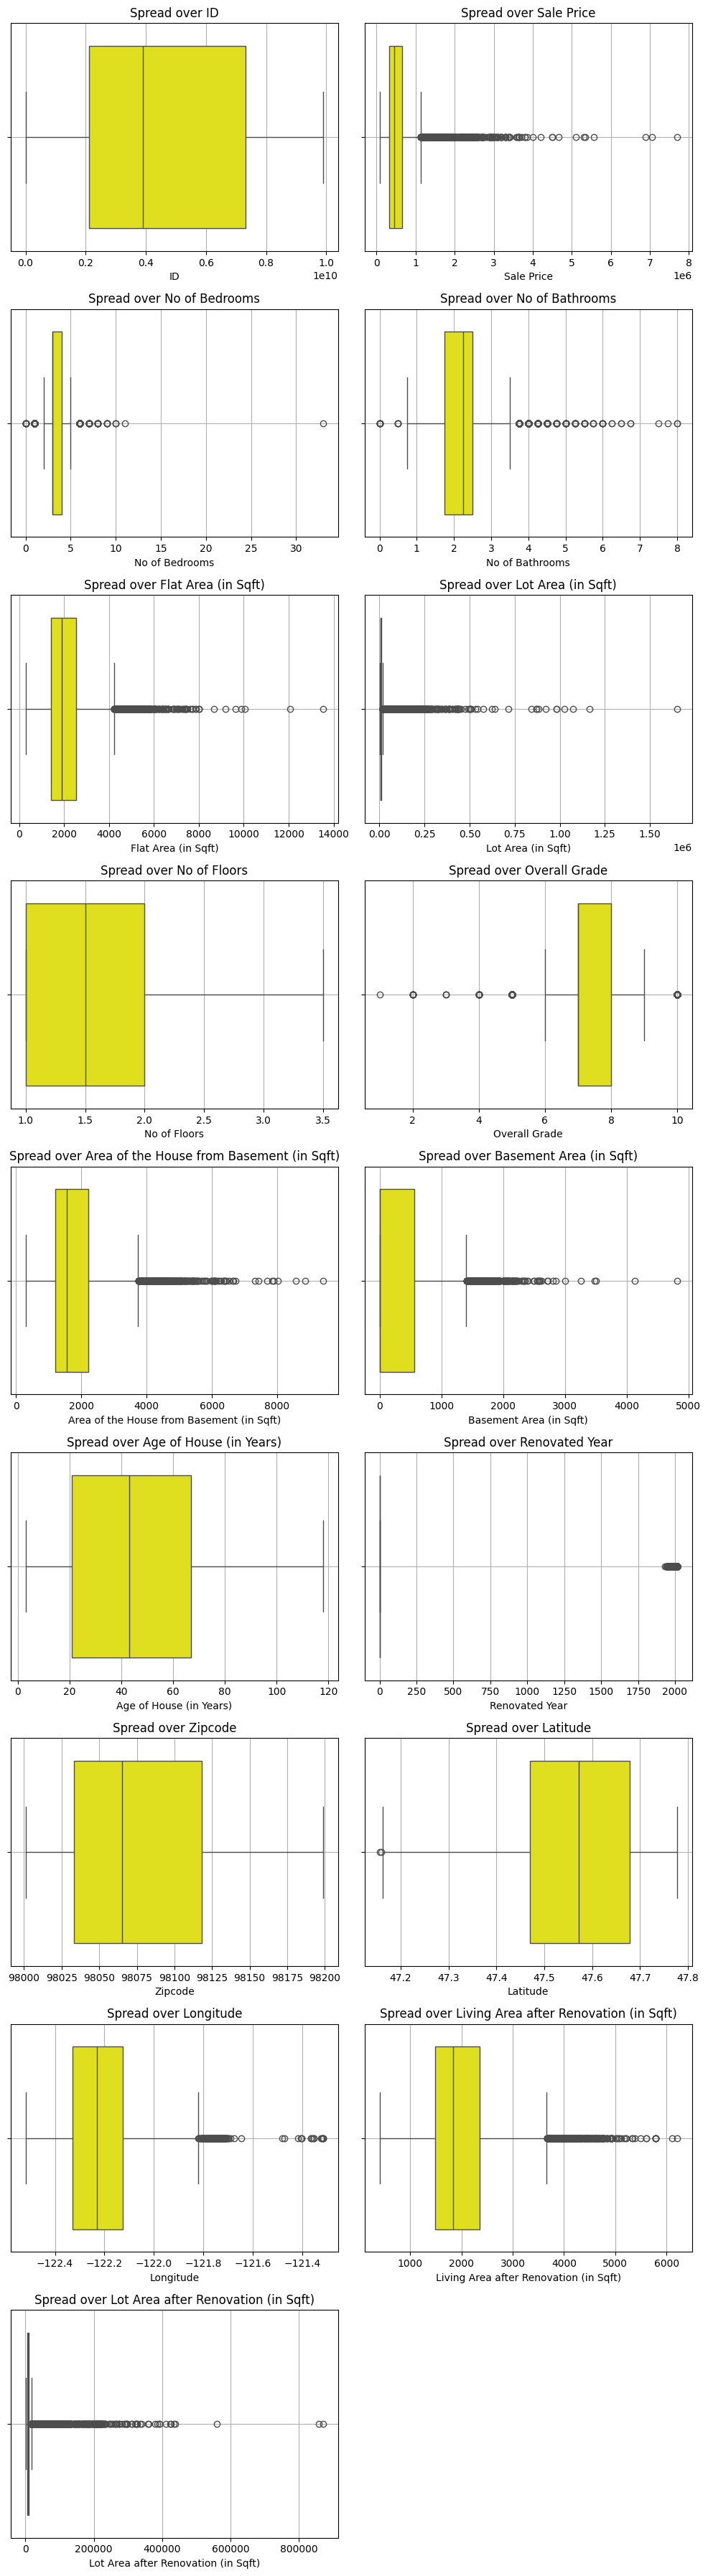

In [49]:
num_col=df.select_dtypes(include='number').columns
row=math.ceil(len(num_col)/2)
plt.figure(figsize=(10,row*4))
for i,col in enumerate(num_col):
  plt.subplot(row,2,i+1)
  sns.boxplot(data=df,x=col,color='yellow')
  plt.xlabel(col)
  plt.title(f'Spread over {col}')
  plt.grid()
plt.tight_layout()
plt.show()


In [52]:
outlier_col=[
    'No of Bedrooms',
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Basement Area (in Sqft)',
    'Age of House (in Years)',
    'Living Area after Renovation (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]



In [55]:
def handle_outlier(col):
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1

  upper_b=Q3+1.5*IQR
  lower_b=Q1-1.5*IQR
  df[col]=df[col].clip(lower=lower_b,upper=upper_b)
for col in outlier_col:
  handle_outlier(col)

# Encoding

In [57]:
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
  print(f'{col} ---{df[col].nunique()}')
  print(f'{df[col].unique()}')

Waterfront View ---2
['No' 'Yes']
Condition of the House ---5
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [59]:
#Label Encoding
label_encoding=['Waterfront View','Condition of the House']
label=LabelEncoder()
for col in label_encoding:
  df[col]=label.fit_transform(df[col])


#Feature Extraction

In [60]:
df['Date House was Sold'].dtype

dtype('<M8[ns]')

In [61]:
df['Year Sold']=df['Date House was Sold'].dt.year
df['Month Sold']=df['Date House was Sold'].dt.month

In [62]:
df.drop(columns=['Date House was Sold'])

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year Sold,Month Sold
0,7129300520,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650.0,2017,10
1,6414100192,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639.0,2017,12
2,5631500400,180000.0,2.0,1.00,770.0,10000.0,1.0,0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062.0,2016,2
3,2487200875,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,1,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000.0,2017,12
4,1954400510,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503.0,2016,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3.0,2.50,1530.0,1131.0,3.0,0,2,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509.0,2017,5
21609,6600060120,400000.0,4.0,2.50,2310.0,5813.0,2.0,0,2,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200.0,2016,2
21610,1523300141,402101.0,2.0,0.75,1020.0,1350.0,2.0,0,2,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007.0,2017,6
21611,291310100,400000.0,3.0,2.50,1600.0,2388.0,2.0,0,2,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287.0,2016,1


#Feature Selection

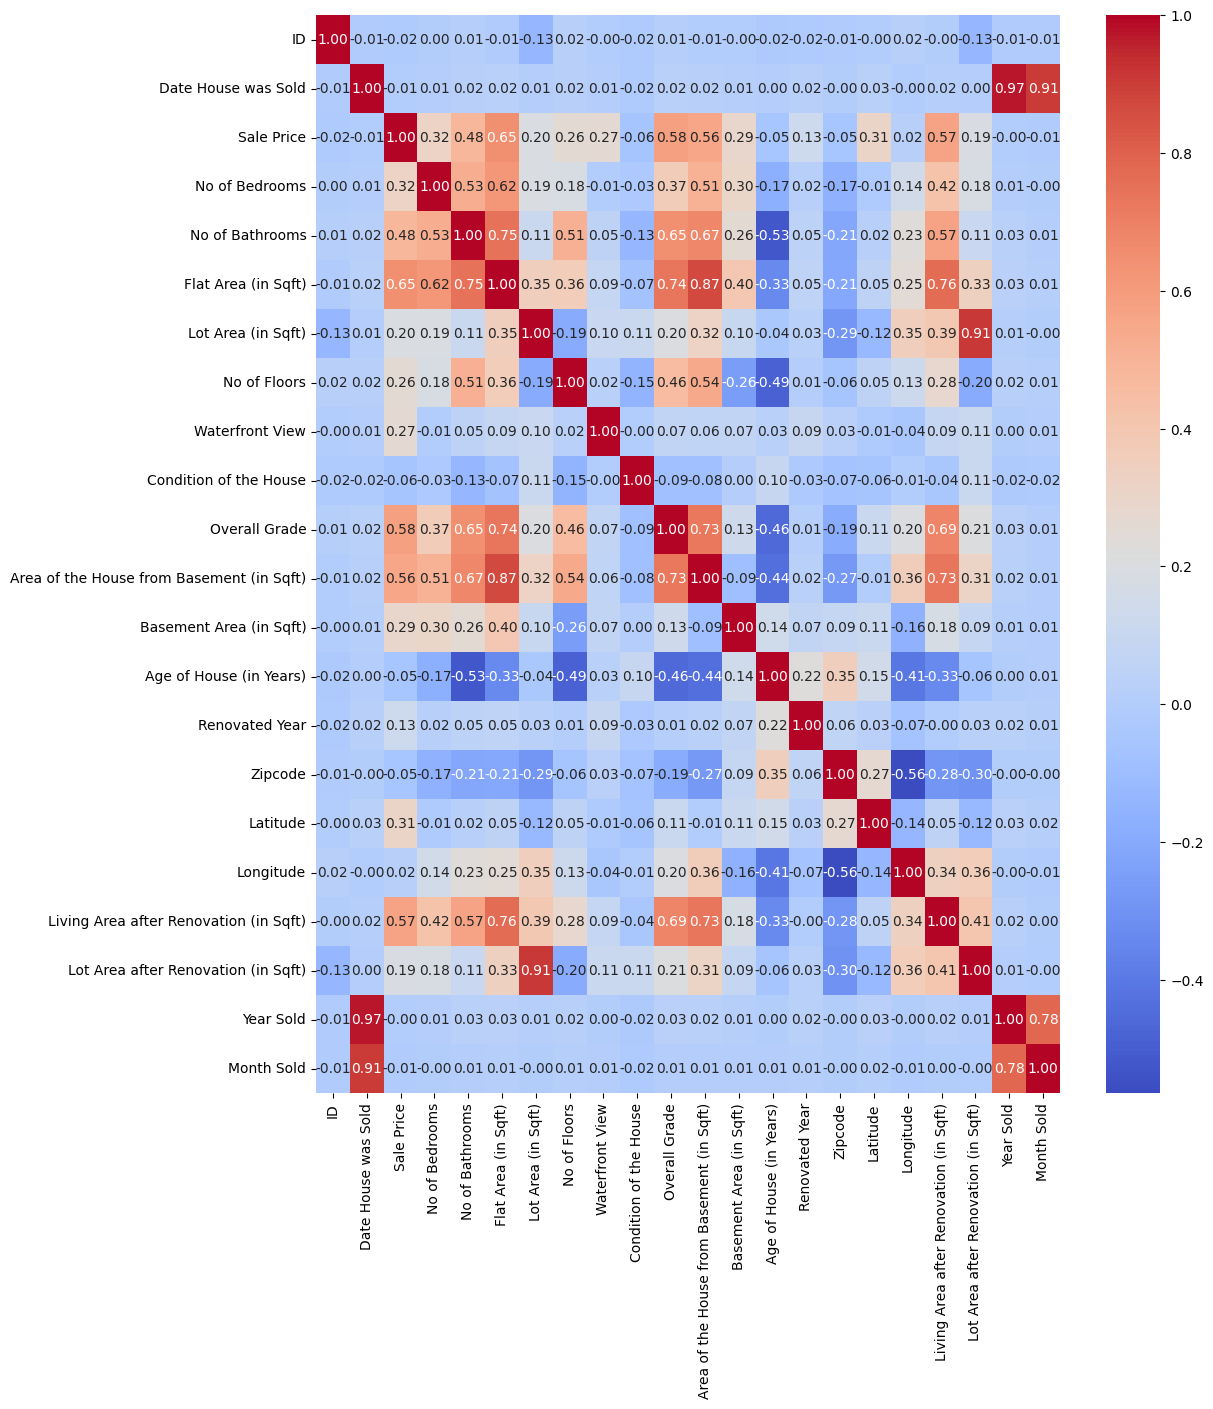

In [79]:
corr=df.corr()
plt.figure(figsize=(12,14))
sns.heatmap(data=corr,annot=True,fmt='.2f',cmap='coolwarm')

plt.show()

In [82]:
print(df.corr()['Sale Price'][lambda x:x.abs()>0.3])

Sale Price                                   1.000000
No of Bedrooms                               0.318190
No of Bathrooms                              0.480812
Flat Area (in Sqft)                          0.646660
Overall Grade                                0.580509
Area of the House from Basement (in Sqft)    0.559102
Latitude                                     0.306846
Living Area after Renovation (in Sqft)       0.568690
Name: Sale Price, dtype: float64


In [85]:
sel_col=['No of Bedrooms',
          'No of Bathrooms',
          'Flat Area (in Sqft)',
          'Overall Grade',
          'Sale Price'
         ]
df=df[sel_col]
df.head()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Overall Grade,Sale Price
0,3.0,1.00,1180.0,7,221900.0
1,3.0,2.25,2570.0,7,538000.0
2,2.0,1.00,770.0,6,180000.0
3,4.0,3.00,1960.0,7,604000.0
4,3.0,2.00,1680.0,8,510000.0


# Train-Test Split

In [86]:
X=df.drop(columns=['Sale Price'])
y=df['Sale Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)


# Feature Scaling

In [87]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)